In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Data load
df = pd.read_csv("cleanned.csv")
print(df.head())
print(df.columns)
print(df.shape)

   age     sex              cp  trestbps   chol    fbs         restecg  \
0   63    Male  typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male    asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male    asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male     non-anginal     130.0  250.0  False          normal   
4   41  Female  typical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak  num  
0   150.0  False      2.3    0  
1   108.0   True      1.5    2  
2   129.0   True      2.6    1  
3   187.0  False      3.5    0  
4   172.0  False      1.4    0  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'num'],
      dtype='object')
(918, 11)


In [ ]:
# Column names fix
df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','num']

In [ ]:
# check
print(df.head())
print(df.info())

   age     sex              cp  trestbps   chol    fbs         restecg  \
0   63    Male  typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male    asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male    asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male     non-anginal     130.0  250.0  False          normal   
4   41  Female  typical angina     130.0  204.0  False  lv hypertrophy   

   thalach  exang  oldpeak  num  
0    150.0  False      2.3    0  
1    108.0   True      1.5    2  
2    129.0   True      2.6    1  
3    187.0  False      3.5    0  
4    172.0  False      1.4    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol   

In [ ]:
# Target
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
print(df['target'].value_counts())

target
1    508
0    410
Name: count, dtype: int64


In [ ]:
# Basic cleaning
print(df.isnull().sum())
print(df.dtypes)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
num         0
target      0
dtype: int64
age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalach     float64
exang          bool
oldpeak     float64
num           int64
target        int64
dtype: object


In [ ]:
# Features aur target split
X = df.drop(['num', 'target'], axis=1)
y = df['target']

In [ ]:
# Categorical aur numeric columns identify
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang']
Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [ ]:
# build Preprocessing pipeline
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# build 3 models
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [ ]:
# Models train
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
# Predictions
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [ ]:
# Classification report print
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        82
           1       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184

Decision Tree Report
              precision    recall  f1-score   support

           0       0.66      0.65      0.65        82
           1       0.72      0.74      0.73       102

    accuracy                           0.70       184
   macro avg       0.69      0.69      0.69       184
weighted avg       0.70      0.70      0.70       184

Random Forest Report
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        82
           1       0.83      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weigh

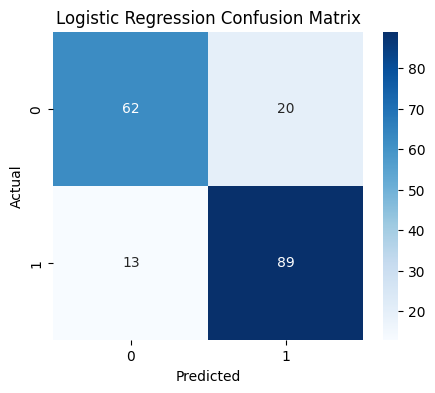

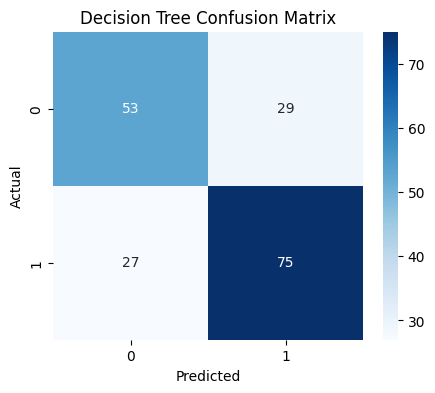

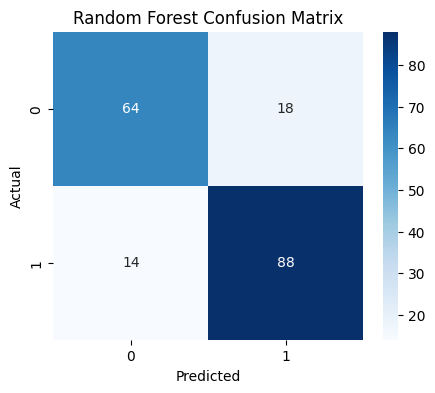

In [ ]:
# Confusion matrix plot
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, lr_pred, "Logistic Regression Confusion Matrix")
plot_cm(y_test, dt_pred, "Decision Tree Confusion Matrix")
plot_cm(y_test, rf_pred, "Random Forest Confusion Matrix")

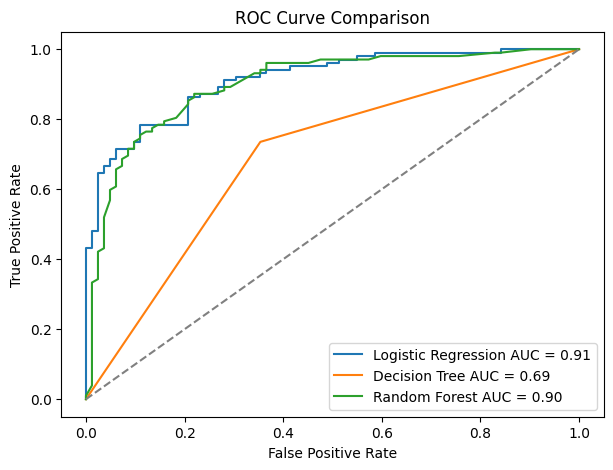

In [ ]:
# bulid ROC curve
lr_prob = lr_model.predict_proba(X_test)[:, 1]
dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_lr = roc_auc_score(y_test, lr_prob)
auc_dt = roc_auc_score(y_test, dt_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {auc_lr:.2f}")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {auc_dt:.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.2f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# Best model choose
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'AUC': [auc_lr, auc_dt, auc_rf]
})

print(results)

                 Model  Accuracy       AUC
0  Logistic Regression  0.820652  0.912004
1        Decision Tree  0.695652  0.690818
2        Random Forest  0.826087  0.898972


In [ ]:
# This project uses supervised machine learning to predict heart disease using patient attributes.
# The target was derived from the num outcome field and converted into binary form for classification.